Experiment            n   Final mean    Final std   Unstable mean  Unstable std
-------------------------------------------------------------------------------------
baseline              9        1.478        0.301            0.00          0.00
cold-start            3        2.299        1.204            0.00          0.00
low forgetting        3        1.363        0.328            0.00          0.00
high forgetting       5        1.804        0.300            0.00          0.00


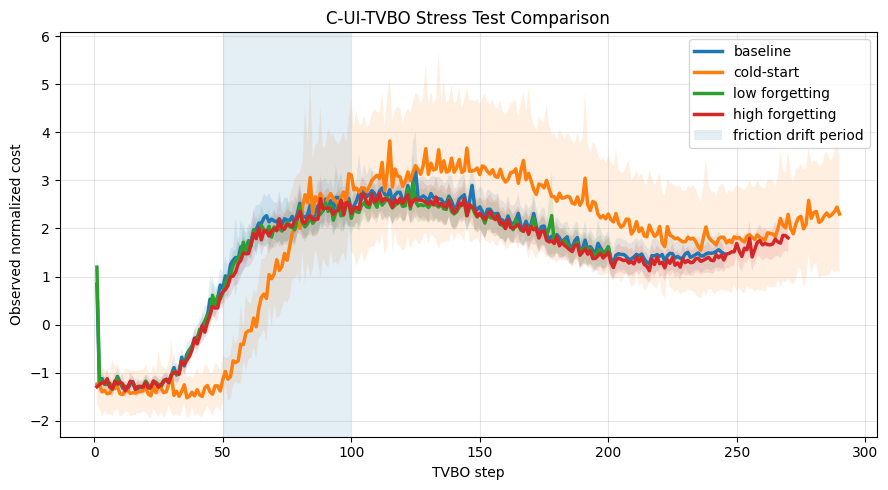

In [1]:
import os, glob, pickle
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = "results"   # 如果文件在 results/baseline 里，就改成 "results/baseline"

experiments = {
    "baseline": {
        "pattern": "results_UI_2DLQR_constrained_forgetting_factor_0_03_baseline_0_03_*.pickle",
        "n_initial": 30,
    },
    "cold-start": {
        "pattern": "results_UI_2DLQR_constrained_forgetting_factor_0_03_coldstart_0_03_*.pickle",
        "n_initial": 10,
    },
    "low forgetting": {
        "pattern": "results_UI_2DLQR_constrained_forgetting_factor_0_01_lowf_0_01_*.pickle",
        "n_initial": 30,
    },
    "high forgetting": {
        "pattern": "results_UI_2DLQR_constrained_forgetting_factor_0_1_highf_0_1_*.pickle",
        "n_initial": 30,
    },
}

def load_pickles(pattern):
    files = sorted(glob.glob(os.path.join(BASE_DIR, pattern)))
    trials = []
    for f in files:
        with open(f, "rb") as fh:
            trials.append(pickle.load(fh))
    return trials

def get_curve(data, n_initial):
    f = np.asarray(data["f_of_x"]).reshape(-1)
    return f[n_initial:]

def count_unstable(data, n_initial):
    return sum(1 for s in data["stable"][n_initial:] if not s)

summary = {}

plt.figure(figsize=(9, 5))

print(f"{'Experiment':<18} {'n':>4} {'Final mean':>12} {'Final std':>12} {'Unstable mean':>15} {'Unstable std':>13}")
print("-" * 85)

for label, cfg in experiments.items():
    trials = load_pickles(cfg["pattern"])
    if len(trials) == 0:
        print(f"{label:<18} NO FILES FOUND")
        continue

    curves = [get_curve(d, cfg["n_initial"]) for d in trials]
    min_len = min(len(c) for c in curves)
    curves = np.array([c[:min_len] for c in curves])

    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)
    t = np.arange(1, min_len + 1)

    unstable = [count_unstable(d, cfg["n_initial"]) for d in trials]

    summary[label] = {
        "n": len(trials),
        "final_mean": mean_curve[-1],
        "final_std": std_curve[-1],
        "unstable_mean": np.mean(unstable),
        "unstable_std": np.std(unstable),
    }

    plt.plot(t, mean_curve, linewidth=2.5, label=label)
    plt.fill_between(t, mean_curve - std_curve, mean_curve + std_curve, alpha=0.12)

    print(f"{label:<18} {len(trials):>4} {mean_curve[-1]:>12.3f} {std_curve[-1]:>12.3f} "
          f"{np.mean(unstable):>15.2f} {np.std(unstable):>13.2f}")

plt.axvspan(50, 100, alpha=0.12, label="friction drift period")
plt.xlabel("TVBO step")
plt.ylabel("Observed normalized cost")
plt.title("C-UI-TVBO Stress Test Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/cui_stress_comparison.png", dpi=300, bbox_inches="tight")
plt.show()